### This notebook chooses and then saves the anchor frames to use from the full observation to build the structure from motion maps

In [ ]:
import glob
import json
import os
import shutil
import time

from dotenv import load_dotenv
from imutils.video import FileVideoStream

import cv2
import pandas as pd
import numpy as np


from koger_detection.landscape.drone_movement import get_anchor_frames_without_log

In [ ]:
video_name = "bear_big2a_2023_08_16_koger_01_01_DJI_20230816175814_0573_D"
video_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), video_name, "media")
video_file = os.path.join(video_folder, video_name + ".MP4")

if os.path.exists(video_file):
    print(f"video exists")

out_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), video_name, "anchor-images")
os.makedirs(out_folder, exist_ok=True)

In [3]:
os.path.exists(video_file)

True

### A new anchor frame is choosen whenever the number of tracked local features in a frame drops below 100

In [4]:
anchor_info, final_warps = get_anchor_frames_without_log(video_file, out_folder, 
                                                         video_name, inlier_threshold=100,
                                                         max_pseudo_anchors=1,
                                                         ransac_reproj_threshold=5)

0 frames processed.  0 anchors saved.
2000 frames processed.  1 anchors saved.
4000 frames processed.  29 anchors saved.
6000 frames processed.  48 anchors saved.
Empty frame. Ending stream.


In [29]:
final_warps[0]

array([[ 9.96502563e-01, -8.28306907e-04, -1.20247189e+02],
       [ 8.28306907e-04,  9.96502563e-01, -1.50800771e+01],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [19]:
# # Save anchor frames for structure from motion processing
anchor_info.to_csv(os.path.join(out_folder, "anchor_frame_info.csv"), index=False)

### Use below code to check quality of warps between anchor frames (these warps are just for checking, won't be used elsewhere in method)

In [23]:
import matplotlib.pyplot as plt
a_ind = 0

anchor_files = [f for f in list(anchor_info['filename'])]

frame0_raw = cv2.imread(anchor_files[a_ind])
frame0_gray = cv2.cvtColor(frame0_raw, cv2.COLOR_BGR2GRAY)

frame1_raw = cv2.imread(anchor_files[a_ind+1])
frame1_gray = cv2.cvtColor(frame1_raw, cv2.COLOR_BGR2GRAY)

warp = final_warps[a_ind]

warped_image = cv2.warpAffine(frame1_gray, M=warp[:2], 
                              dsize=(frame0_raw.shape[1], frame0_raw.shape[0]))

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(frame1_gray, alpha=.5, cmap='gray')
plt.title("No Correction")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(warped_image, alpha=.5, cmap='gray')
plt.title("Corrected")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.title("Frame 0 raw")
plt.figure(figsize=(20,20))
plt.imshow(frame1_gray, alpha=1.0, cmap='gray')
plt.title("Frame 1 raw")

[ WARN:0@15770.759] global loadsave.cpp:268 findDecoder imread_('/mnt/c/Users/benko/Documents/local_projects/bears/bear_big2a_2023_08_16_koger_01_01_DJI_20230816175814_0573_D-debug/bear_big2a_2023_08_16_koger_01_01_DJI_20230816175814_0573_D-00000.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


Text(0.5, 1.0, 'Frame 1 raw')

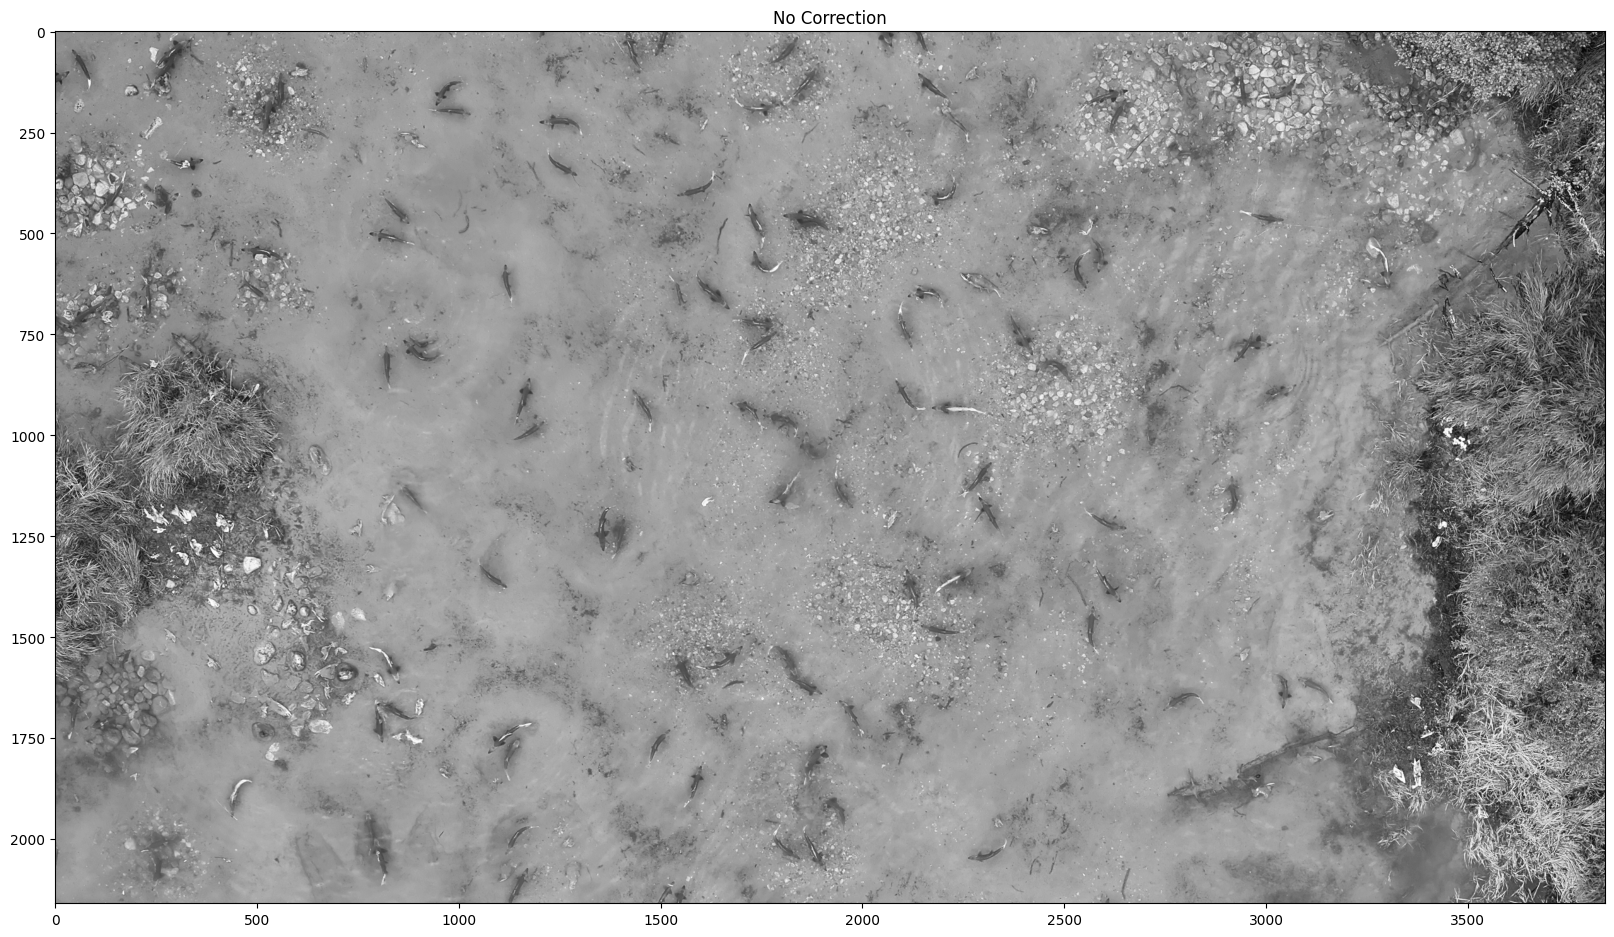

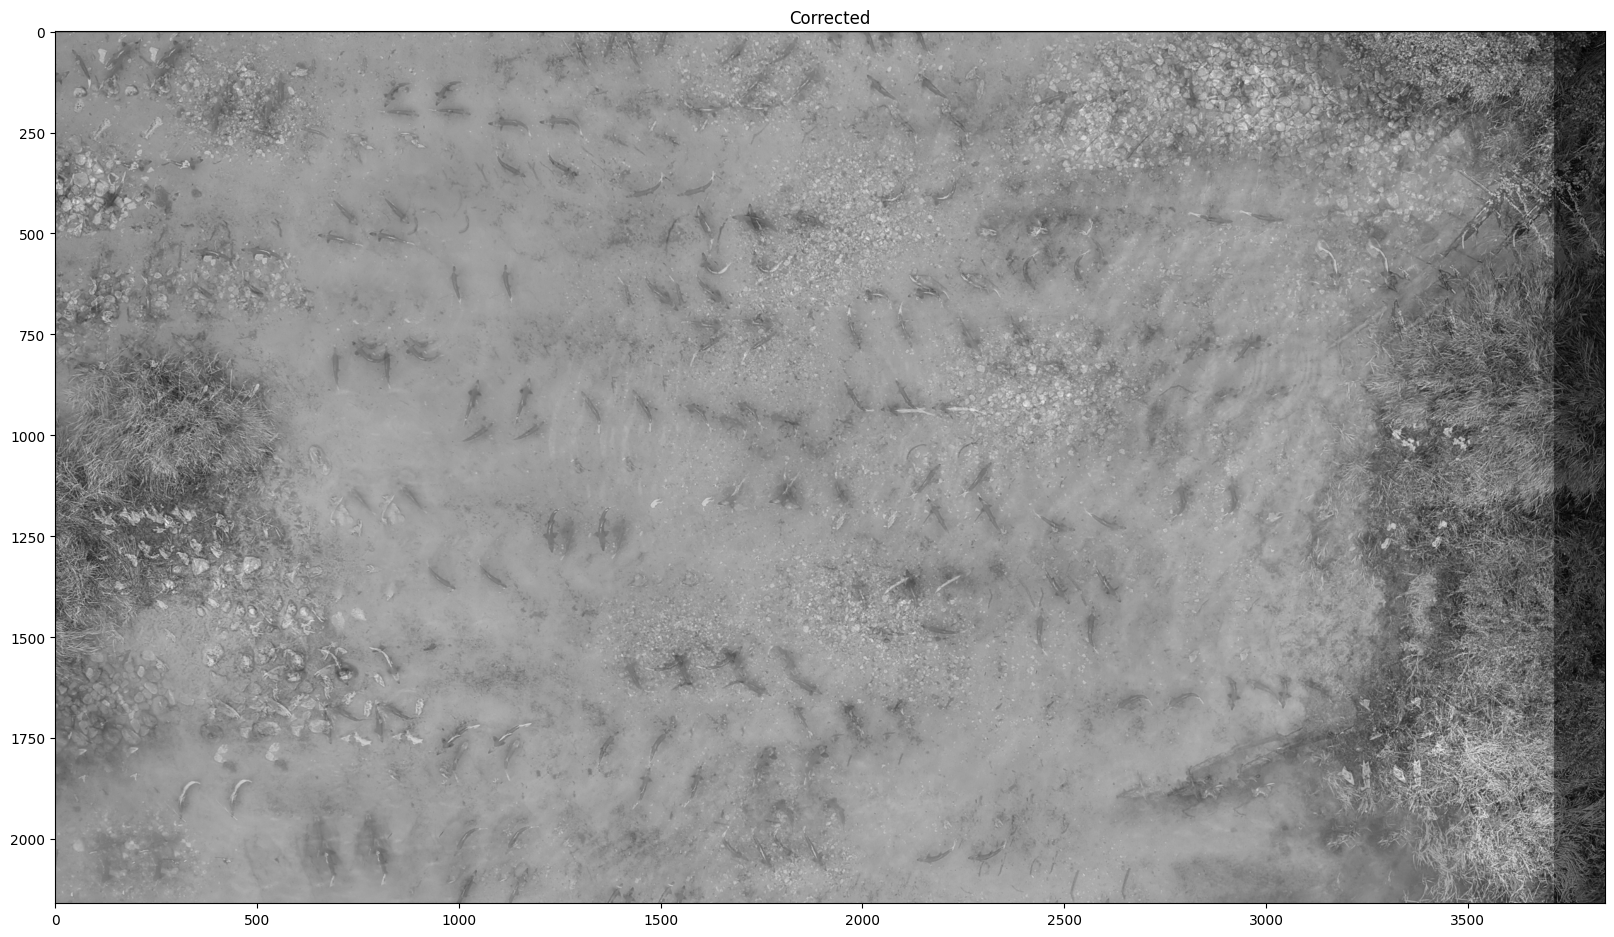

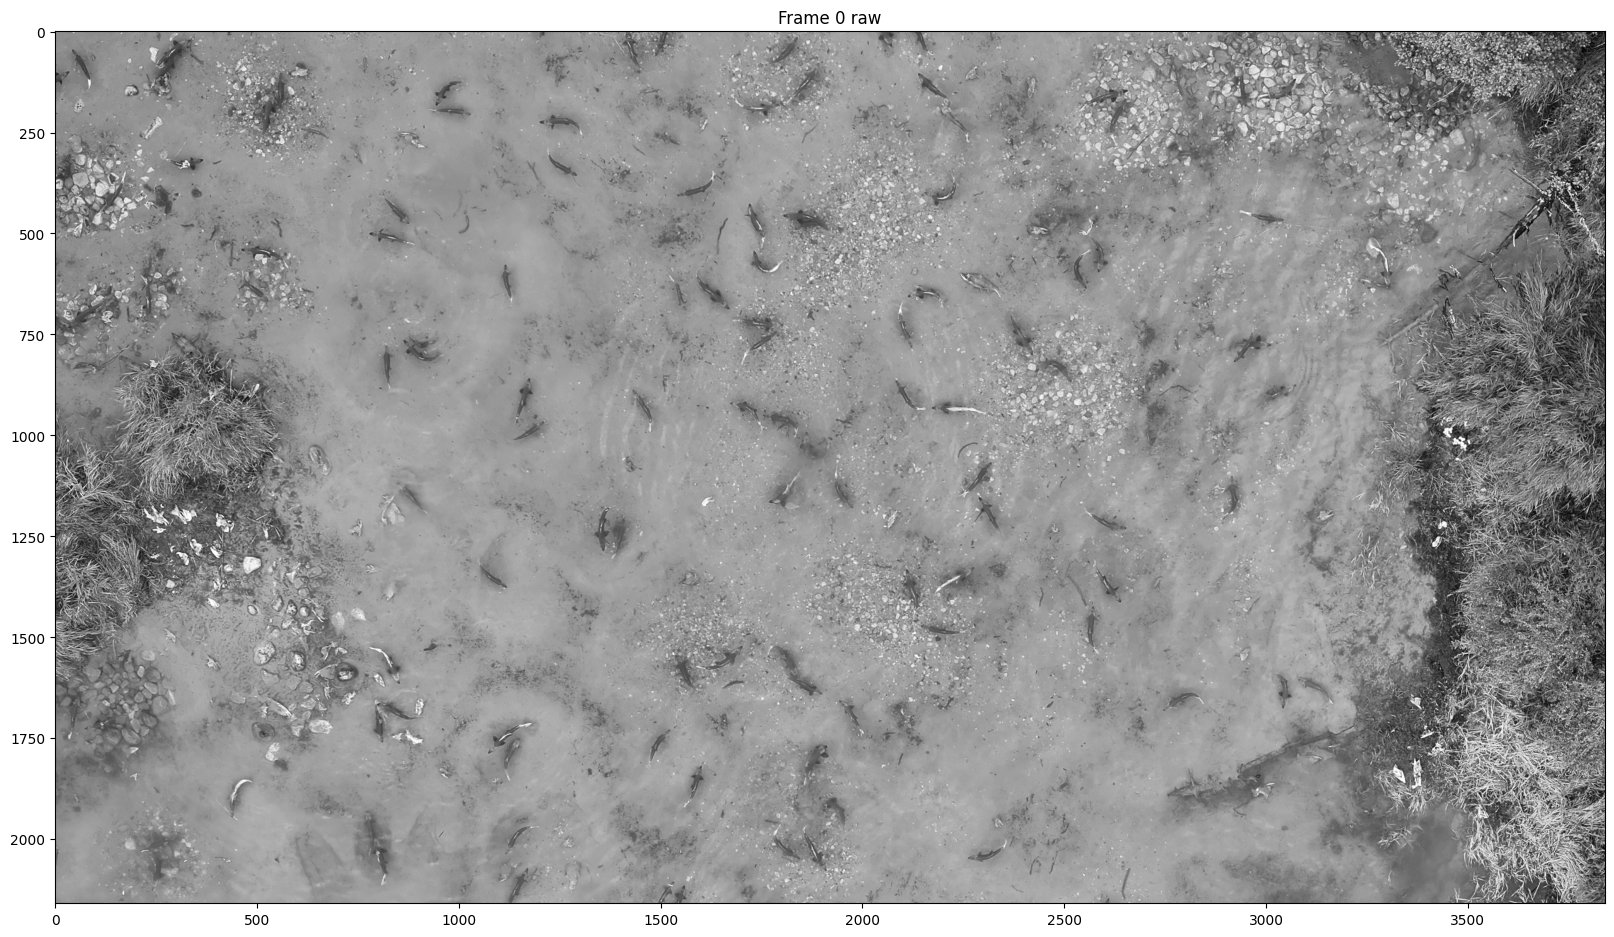

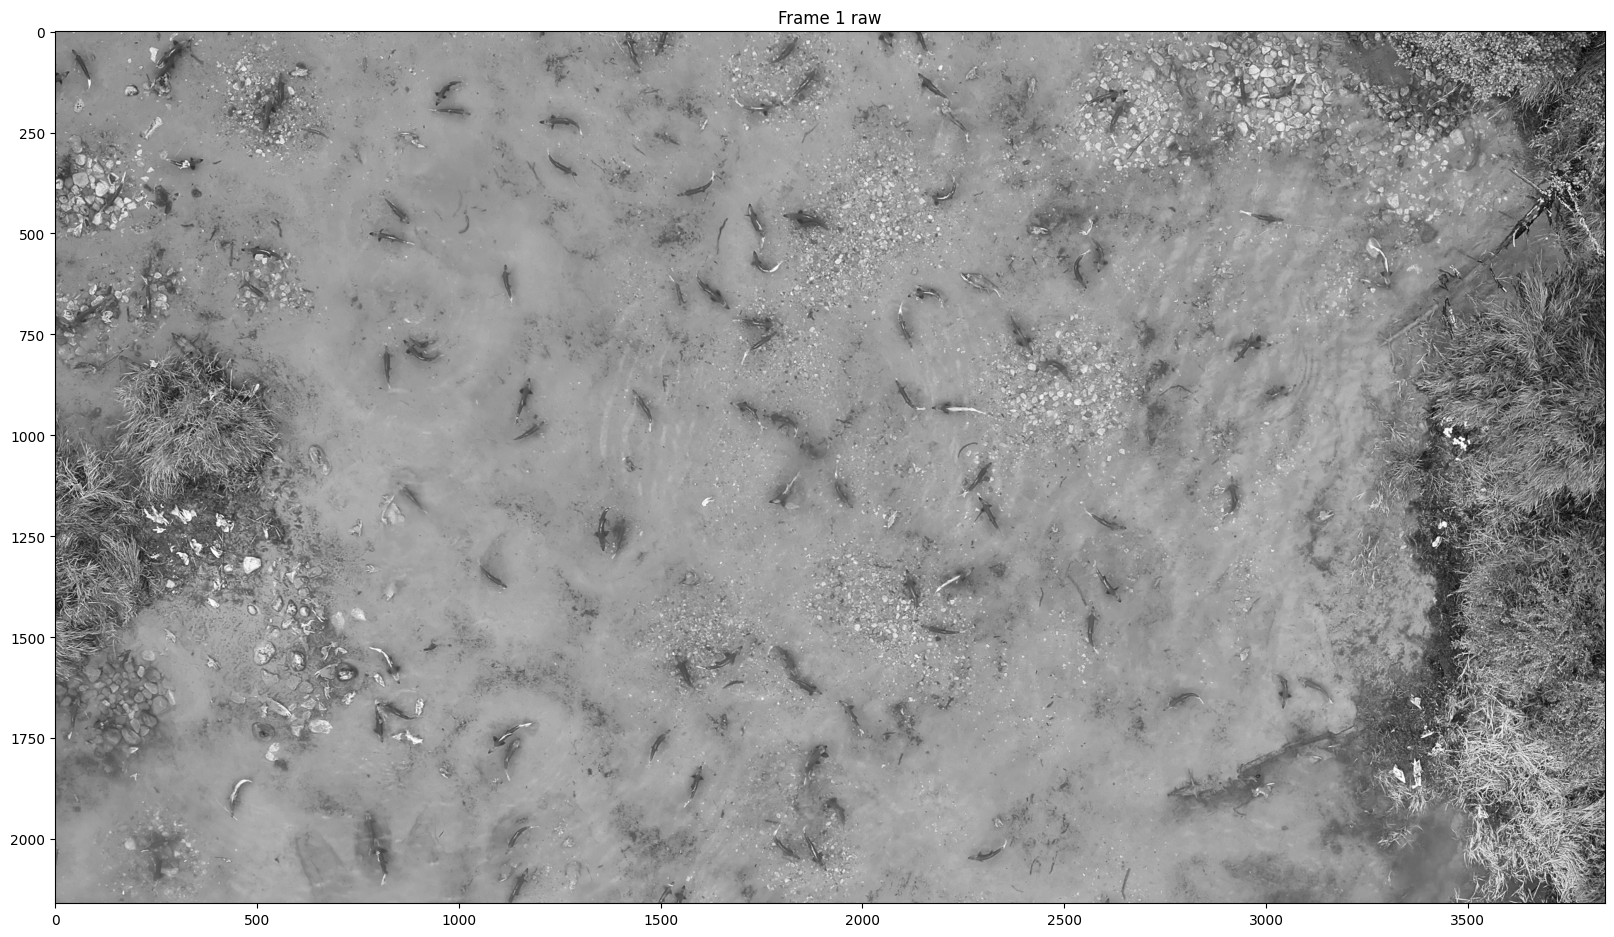

In [31]:
import matplotlib.pyplot as plt
a_ind = 0

anchor_files = [f for f in list(anchor_info['filename'])]

frame0_raw = cv2.imread(anchor_files[a_ind])
frame0_gray = cv2.cvtColor(frame0_raw, cv2.COLOR_BGR2GRAY)

frame1_raw = cv2.imread(anchor_files[a_ind])
frame1_gray = cv2.cvtColor(frame1_raw, cv2.COLOR_BGR2GRAY)

warp = final_warps[1]

warped_image = cv2.warpAffine(frame1_gray, M=warp[:2], 
                              dsize=(frame0_raw.shape[1], frame0_raw.shape[0]))

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(frame1_gray, alpha=.5, cmap='gray')
plt.title("No Correction")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(warped_image, alpha=.5, cmap='gray')
plt.title("Corrected")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.title("Frame 0 raw")
plt.figure(figsize=(20,20))
plt.imshow(frame1_gray, alpha=1.0, cmap='gray')
plt.title("Frame 1 raw")